# ACLED Gaza Hawkes deep dive and practical improvements

This notebook is a focused follow-on to the rolling ACLED vignette. The goal here is not just to run the model, but to understand **why** the current example behaves the way it does and to put a more defensible modeling workflow into practice.

There are three questions motivating the analysis.

First, is the model actually marked, or are we effectively fitting a single total-count process? Second, why does the model struggle on large 2-week totals and spatial long tails? Third, why can a pure road prior perform worse than a simple agnostic spatial kernel even though roads seem like useful prior structure?

The short answers are these. The model **is** genuinely marked: the count tensor is `[T, J, M]`, the excitation matrix is mark-to-mark, and the forecast is generated jointly over marks. However, many of the headline plots in the earlier notebook collapse over the mark dimension, so the outputs *look* like total-only diagnostics. The heavy-count behavior is mainly a consequence of fitting a relatively parameter-rich Hawkes model with a **toy optimization budget**, a **Poisson observation model**, and only **one or two 2-week bins of history** in the earliest splits. The road-prior result is weaker because the notebook used a **pure road graph**, mapped an extremely rich OSM network onto a coarse lattice, and allowed footways, tracks, and other minor links to influence the prior almost as much as more plausible movement corridors.

In this notebook we keep the same deterministic ACLED snapshot and the same 2-week task framing, but we make four concrete changes.

We replace the Poisson likelihood with an NB2 count model so the forecast can express extra-Poisson dispersion. We increase the temporal basis count and give MAP fitting a real optimization budget instead of treating it as a toy run. We evaluate forecasts primarily **inside the Gaza mask** so the metrics are not dominated by always-zero cells outside the polygon. And instead of using a pure road graph as the only spatial pathway, we build a **hybrid local-plus-road prior** that treats roads as a soft directional cue rather than a hard replacement for local spillover.

The output is therefore both a diagnosis and an updated recipe for getting better behavior from the current mobility-Hawkes implementation on ACLED Gaza.

In [1]:
import time
NB_START = time.perf_counter()

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.path import Path as MplPath

from motac import EdgeList, EventTable, FitConfig, GridSpec, HawkesModelSpec, MobilityHawkesModel, acled_to_counts
from motac.connectivity import make_grid_edgelist, make_grid_stencil
from motac.eval import score_crps_counts, score_predictive_log_prob_samples

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("docs/tutorials/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]
print("Detected devices:", devices)
print("Default backend:", jax.default_backend())
print("JIT remains enabled unless JAX_DISABLE_JIT is set externally.")
if gpu_devices:
    print(f"GPU devices available: {len(gpu_devices)}")
else:
    print("No CUDA-enabled JAX backend detected for this run.")

Detected devices: [CudaDevice(id=0)]
Default backend: gpu
JIT remains enabled unless JAX_DISABLE_JIT is set externally.
GPU devices available: 1


## What the current model is really doing

The ACLED example is already using a **marked** Hawkes process. The data are converted into a tensor of shape `[time, node, mark]`, the model learns a mark-to-mark excitation matrix, and each forecast draw is a full joint sample over all marks. If the notebook looks like it is only modeling totals, that is mostly because many of the spatial maps and summary metrics are built from arrays that have already been summed over the mark axis for readability.

The deeper issue is not that the model ignores marks. The deeper issue is that the current likelihood and parameterization place a lot of pressure on a small amount of information. The tutorial notebook sets `observation="poisson"`, uses only two temporal bases, and fits with `map_steps=6` and `map_ensemble_size=1`. That is a deliberately lightweight tutorial configuration, but it is too weak to be a strong ACLED forecasting recipe. The Poisson likelihood is especially restrictive here because the 2-week counts are visibly overdispersed relative to Poisson behavior.

There is also an important structural limitation in the current implementation. The baseline intensity `mu` is **mark-specific but not node-specific**. In other words, the model can learn that explosions are more common than VAC events in aggregate, but it cannot directly learn that some cells in Gaza are chronically hotter than others except through self- and neighbor-excitation. For conflict data, that matters: persistent spatial heterogeneity is real, and forcing all of it through the excitation mechanism can make the model either too conservative on peaks or too sticky after a burst.

Finally, some of the default evaluation numbers in the earlier vignette are kinder than they look. The raw predictive log score, CRPS, and coverage from the generic backtest operate on the full rectangular lattice. Because many cells outside the Gaza polygon are always zero, those metrics are partially dominated by easy zero predictions. For a more honest ACLED assessment we want to score primarily on the active Gaza mask and inspect the total-count tail behavior directly.

In [2]:
snapshot_path = DATA_DIR / "acled_events_example.csv"
if not snapshot_path.exists():
    raise FileNotFoundError(f"Missing snapshot: {snapshot_path}")

GAZA_BOUNDARY_CACHE = DATA_DIR / "gaza_boundary.geojson"
ROAD_SEGMENTS_CACHE = DATA_DIR / "gaza_osm_roads_segments.csv"
DEFAULT_GAZA_BBOX = (34.2, 34.6, 31.2, 31.6)
ROAD_REQUIRED_COLS = ["lon0", "lat0", "lon1", "lat1", "highway"]


def close_ring(coords: np.ndarray) -> np.ndarray:
    arr = np.asarray(coords, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("Polygon coordinates must have shape [N, 2].")
    if len(arr) < 3:
        raise ValueError("Polygon ring must contain at least 3 coordinates.")
    if not np.allclose(arr[0], arr[-1]):
        arr = np.vstack([arr, arr[0]])
    return arr


def ring_area(coords: np.ndarray) -> float:
    arr = close_ring(coords)
    x = arr[:, 0]
    y = arr[:, 1]
    return 0.5 * abs(np.dot(x[:-1], y[1:]) - np.dot(y[:-1], x[1:]))


def extract_outer_ring(geometry: dict[str, object]) -> np.ndarray:
    geom_type = geometry.get("type")
    coords = geometry.get("coordinates")

    if geom_type == "Polygon":
        if not coords:
            raise ValueError("Polygon geometry contains no coordinates.")
        return close_ring(np.asarray(coords[0], dtype=float))

    if geom_type == "MultiPolygon":
        if not coords:
            raise ValueError("MultiPolygon geometry contains no coordinates.")
        rings = [close_ring(np.asarray(poly[0], dtype=float)) for poly in coords if poly]
        if not rings:
            raise ValueError("MultiPolygon geometry contains no polygon rings.")
        return max(rings, key=ring_area)

    raise ValueError(f"Unsupported boundary geometry type: {geom_type}")


def load_gaza_outline(boundary_path: Path, fallback_bbox: tuple[float, float, float, float]) -> np.ndarray:
    if boundary_path.exists():
        payload = json.loads(boundary_path.read_text())
        features = payload.get("features", [])
        if not features:
            raise ValueError(f"Boundary cache exists but contains no features: {boundary_path}")
        return extract_outer_ring(features[0]["geometry"])

    lon_min, lon_max, lat_min, lat_max = fallback_bbox
    return close_ring(
        np.array(
            [
                [lon_min, lat_min],
                [lon_max, lat_min],
                [lon_max, lat_max],
                [lon_min, lat_max],
            ],
            dtype=float,
        )
    )


def collapse_event_type(value: object) -> str:
    text = str(value)
    if text == "Explosions/Remote violence":
        return "Explosion"
    if text == "Battles":
        return "Battle"
    if text in {"Riots", "Protests"}:
        return "Riot/Protest"
    if text == "Violence against civilians":
        return "VAC"
    return "Other"


gaza_outline_lonlat = load_gaza_outline(GAZA_BOUNDARY_CACHE, DEFAULT_GAZA_BBOX)
gaza_path_lonlat = MplPath(gaza_outline_lonlat)
GAZA_BBOX = (
    float(gaza_outline_lonlat[:, 0].min()),
    float(gaza_outline_lonlat[:, 0].max()),
    float(gaza_outline_lonlat[:, 1].min()),
    float(gaza_outline_lonlat[:, 1].max()),
)

EARTH_RADIUS_M = 6_371_000.0
center_lon = 0.5 * (GAZA_BBOX[0] + GAZA_BBOX[1])
center_lat = 0.5 * (GAZA_BBOX[2] + GAZA_BBOX[3])
cos_center_lat = np.cos(np.deg2rad(center_lat))


def lonlat_to_local_xy(lon: np.ndarray | float, lat: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    lon_arr = np.asarray(lon, dtype=float)
    lat_arr = np.asarray(lat, dtype=float)
    x = np.deg2rad(lon_arr - center_lon) * EARTH_RADIUS_M * cos_center_lat
    y = np.deg2rad(lat_arr - center_lat) * EARTH_RADIUS_M
    return x, y


def local_xy_to_lonlat(x: np.ndarray | float, y: np.ndarray | float) -> tuple[np.ndarray, np.ndarray]:
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    lon = center_lon + np.rad2deg(x_arr / (EARTH_RADIUS_M * max(cos_center_lat, 1e-8)))
    lat = center_lat + np.rad2deg(y_arr / EARTH_RADIUS_M)
    return lon, lat


def draw_polygon_outline(ax, polygon_xy: np.ndarray, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    ax.plot(polygon_xy[:, 0], polygon_xy[:, 1], color=color, linewidth=linewidth, alpha=alpha)


def draw_gaza_outline(ax, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    draw_polygon_outline(ax, gaza_outline_lonlat, color=color, linewidth=linewidth, alpha=alpha)


def draw_gaza_outline_projected(ax, *, color: str = "black", linewidth: float = 1.0, alpha: float = 0.95) -> None:
    draw_polygon_outline(ax, gaza_outline_xy, color=color, linewidth=linewidth, alpha=alpha)


_df_raw = pd.read_csv(snapshot_path, low_memory=False)
required_cols = {"event_date", "latitude", "longitude", "event_type"}
missing = required_cols - set(_df_raw.columns)
if missing:
    raise ValueError(f"ACLED snapshot missing required columns: {sorted(missing)}")

df = _df_raw.copy()
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce").dt.floor("D")
df = df.dropna(subset=["event_date", "latitude", "longitude", "event_type"]).copy()
df = df[
    df["longitude"].between(GAZA_BBOX[0], GAZA_BBOX[1])
    & df["latitude"].between(GAZA_BBOX[2], GAZA_BBOX[3])
].copy()

if not df.empty:
    inside_gaza = gaza_path_lonlat.contains_points(
        df[["longitude", "latitude"]].to_numpy(dtype=float),
        radius=1e-9,
    )
    df = df.loc[inside_gaza].copy()

if df.empty:
    raise ValueError("No ACLED events remain after applying the Gaza polygon filter.")

df["event_type_group"] = df["event_type"].map(collapse_event_type)
window_start = df["event_date"].max() - pd.Timedelta(days=730)
df = df[df["event_date"] >= window_start].copy()
top_marks = df["event_type_group"].value_counts().head(4).index.tolist()
df = df[df["event_type_group"].isin(top_marks)].copy().sort_values("event_date").reset_index(drop=True)

proj_x, proj_y = lonlat_to_local_xy(
    df["longitude"].to_numpy(dtype=float),
    df["latitude"].to_numpy(dtype=float),
)
df_model = df.rename(columns={"event_type_group": "event_type_model"}).copy()
df_model["x_proj"] = proj_x
df_model["y_proj"] = proj_y

gaza_outline_x, gaza_outline_y = lonlat_to_local_xy(gaza_outline_lonlat[:, 0], gaza_outline_lonlat[:, 1])
gaza_outline_xy = np.column_stack([gaza_outline_x, gaza_outline_y])
gaza_path_xy = MplPath(gaza_outline_xy)
projected_extent = (
    float(gaza_outline_xy[:, 0].min()),
    float(gaza_outline_xy[:, 0].max()),
    float(gaza_outline_xy[:, 1].min()),
    float(gaza_outline_xy[:, 1].max()),
)

print("Loaded rows (post-filter):", len(df_model))
print("Date range:", df_model["event_date"].min().date(), "->", df_model["event_date"].max().date())
print("Grouped marks:", top_marks)
print("Road cache present:", ROAD_SEGMENTS_CACHE.exists())
df_model[["event_date", "longitude", "latitude", "event_type_model"]].head(3)

Loaded rows (post-filter): 15561
Date range: 2023-09-05 -> 2024-12-04
Grouped marks: ['Explosion', 'Battle', 'Other', 'VAC']
Road cache present: True


,event_date,longitude,latitude,event_type_model
0,2023-09-05,34.4743,31.5045,Explosion
1,2023-09-10,34.3503,31.4178,Other
2,2023-09-12,34.4743,31.5045,Other


## The count regime is strongly overdispersed

Before changing the model, it is worth making the data problem explicit. The 2-week totals in this snapshot are not close to a narrow Poisson regime. The mean 2-week total is in the high hundreds, the variance is much larger than the mean, and the distribution is dominated by a very heavy `Explosion` mark with much smaller but still nontrivial `Battle`, `Other`, and `VAC` series.

That matters for two reasons. A Poisson observation model forces the variance to equal the mean conditional on the latent intensity, so it tends to pull forecast means toward safer central values when the true series has large count volatility. And when the optimization budget is tiny, the model cannot compensate by learning a particularly rich excitation surface. In other words, the earlier notebook was asking a lightly fitted model with limited dispersion to explain a very volatile marked conflict process.

We therefore construct the same 2-week tensor as before, but we keep the diagnostics honest and use them to motivate a stronger forecasting recipe.

In [3]:
cell_size_m = 1_000.0
x_min, x_max, y_min, y_max = projected_extent
width_m = x_max - x_min
height_m = y_max - y_min
n_cols = max(1, int(np.ceil(width_m / cell_size_m)))
n_rows = max(1, int(np.ceil(height_m / cell_size_m)))

grid = GridSpec(shape=(n_rows, n_cols), extent=projected_extent, crs="LOCAL_GAZA_EQUIRECT_M")
H, W = grid.shape
num_nodes = H * W

x_edges = np.linspace(x_min, x_max, W + 1)
y_edges = np.linspace(y_min, y_max, H + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
grid_xx, grid_yy = np.meshgrid(x_centers, y_centers, indexing="xy")
gaza_mask = gaza_path_xy.contains_points(
    np.column_stack([grid_xx.reshape(-1), grid_yy.reshape(-1)]),
    radius=1e-9,
).reshape(H, W)
gaza_mask_flat = gaza_mask.reshape(-1)

events = EventTable(
    df=df_model,
    time_col="event_date",
    lat_col="y_proj",
    lon_col="x_proj",
    mark_col="event_type_model",
)
counts_base = acled_to_counts(events, grid, marks=top_marks, dt_days=14)
counts_conv = counts_base.with_connectivity(make_grid_stencil(kind="gaussian", size=3, sigma=1.0))

preview_splits = counts_conv.rolling_origin_splits(horizon=1, step=1, min_train=1)
split_rows = []
for i, split in enumerate(preview_splits):
    test_start = pd.Timestamp(split.test.t0)
    test_end = test_start + pd.Timedelta(days=split.test.dt_days) - pd.Timedelta(days=1)
    split_rows.append(
        {
            "split": i,
            "test_start": test_start,
            "test_end": test_end,
            "true_total": float(np.asarray(split.test.y).sum()),
        }
    )
split_table = pd.DataFrame(split_rows)

per_bin_total = pd.Series(np.asarray(counts_base.y).sum(axis=(1, 2))).rename("total")
per_bin_mark = pd.DataFrame(
    np.asarray(counts_base.y).sum(axis=1),
    columns=counts_base.marks,
)

overdispersion_rows = []
for mark in counts_base.marks:
    vals = per_bin_mark[mark].to_numpy(dtype=float)
    overdispersion_rows.append(
        {
            "mark": mark,
            "mean_2week_total": vals.mean(),
            "var_2week_total": vals.var(),
            "max_2week_total": vals.max(),
            "q95_2week_total": np.quantile(vals, 0.95),
        }
    )
overdispersion_table = pd.DataFrame(overdispersion_rows).round(2)

print("Counts tensor shape [T, J, M]:", counts_base.y.shape)
print("Projected grid shape:", grid.shape)
print("Cells inside Gaza polygon:", int(gaza_mask.sum()), "/", int(gaza_mask.size))
print("2-week total mean:", round(float(per_bin_total.mean()), 2))
print("2-week total variance:", round(float(per_bin_total.var()), 2))
print("2-week total max:", int(per_bin_total.max()))
print("Representative heavy-tail totals:", sorted(per_bin_total.astype(int).tolist(), reverse=True)[:8])
overdispersion_table

Counts tensor shape [T, J, M]: (33, 1428, 4)
Projected grid shape: (42, 34)
Cells inside Gaza polygon: 388 / 1428
2-week total mean: 471.55
2-week total variance: 21775.51
2-week total max: 719
Representative heavy-tail totals: [719, 633, 632, 607, 584, 564, 559, 547]


,mark,mean_2week_total,var_2week_total,max_2week_total,q95_2week_total
0,Explosion,396.91,14110.57,600.0,508.2
1,Battle,41.82,1018.27,117.0,110.4
2,Other,25.91,164.69,46.0,43.8
3,VAC,6.91,38.39,27.0,19.4


In [4]:
def projected_to_node(x: float, y: float) -> int:
    rr = int(np.clip(((y - y_min) / max(y_max - y_min, 1e-8)) * H, 0, H - 1))
    cc = int(np.clip(((x - x_min) / max(x_max - x_min, 1e-8)) * W, 0, W - 1))
    return rr * W + cc


def apply_gaza_mask(arr_2d: np.ndarray) -> np.ndarray:
    masked = np.asarray(arr_2d, dtype=float).copy()
    masked[~gaza_mask] = np.nan
    return masked


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float).reshape(-1)
    b = np.asarray(b, dtype=float).reshape(-1)
    finite = np.isfinite(a) & np.isfinite(b)
    if finite.sum() < 2:
        return float("nan")
    a = a[finite]
    b = b[finite]
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


def flatten_masked_counts(y: np.ndarray) -> np.ndarray:
    arr = np.asarray(y)
    if arr.ndim == 3:
        return arr[:, gaza_mask_flat, :]
    if arr.ndim == 4:
        return arr[:, :, gaza_mask_flat, :]
    raise ValueError(f"Expected ndim 3 or 4, got {arr.ndim}")


def dict_to_edgelist(weight_map: dict[tuple[int, int], float], num_nodes: int, *, meta: dict[str, object]) -> EdgeList:
    triples = [(src, dst, wt) for (src, dst), wt in weight_map.items() if wt > 0.0]
    if not triples:
        raise ValueError("Cannot build EdgeList from an empty weight map.")
    src = np.asarray([t[0] for t in triples], dtype=np.int32)
    dst = np.asarray([t[1] for t in triples], dtype=np.int32)
    wt = np.asarray([t[2] for t in triples], dtype=np.float32)
    row_sum = np.bincount(src, weights=wt, minlength=num_nodes).astype(np.float32)
    wt = wt / np.clip(row_sum[src], 1e-8, None)
    return EdgeList(
        src=jnp.asarray(src, dtype=jnp.int32),
        dst=jnp.asarray(dst, dtype=jnp.int32),
        weight=jnp.asarray(wt, dtype=jnp.float32),
        num_nodes=num_nodes,
        meta=dict(meta),
    )


def edgelist_to_weight_map(edges: EdgeList) -> dict[tuple[int, int], float]:
    out: dict[tuple[int, int], float] = {}
    for src, dst, wt in zip(np.asarray(edges.src), np.asarray(edges.dst), np.asarray(edges.weight)):
        key = (int(src), int(dst))
        out[key] = out.get(key, 0.0) + float(wt)
    return out


def build_masked_local_graph() -> EdgeList:
    full_local = make_grid_edgelist(
        grid,
        neighbourhood="moore",
        weight="uniform",
        directed=True,
        normalise_rows=True,
    )
    weights: dict[tuple[int, int], float] = {}
    for src, dst, wt in zip(np.asarray(full_local.src), np.asarray(full_local.dst), np.asarray(full_local.weight)):
        s = int(src)
        d = int(dst)
        if gaza_mask_flat[s] and gaza_mask_flat[d]:
            weights[(s, d)] = weights.get((s, d), 0.0) + float(wt)
    for node in range(num_nodes):
        if gaza_mask_flat[node]:
            weights[(node, node)] = weights.get((node, node), 0.0) + 0.2
    return dict_to_edgelist(weights, num_nodes, meta={"kind": "masked_local_moore"})


def build_filtered_road_graph(roads_df: pd.DataFrame, *, base_self_mass: float = 0.2) -> EdgeList | None:
    if roads_df.empty:
        return None

    allowed_highways = {
        "motorway",
        "trunk",
        "primary",
        "secondary",
        "tertiary",
        "residential",
        "unclassified",
        "service",
    }
    highway_weight = {
        "motorway": 3.0,
        "trunk": 2.6,
        "primary": 2.2,
        "secondary": 1.7,
        "tertiary": 1.4,
        "residential": 1.0,
        "unclassified": 0.9,
        "service": 0.7,
    }

    roads_use = roads_df[roads_df["highway"].isin(allowed_highways)].copy()
    if roads_use.empty:
        return None

    weights: dict[tuple[int, int], float] = {}
    for node in range(num_nodes):
        if gaza_mask_flat[node]:
            weights[(node, node)] = base_self_mass

    for row in roads_use.itertuples(index=False):
        x0_arr, y0_arr = lonlat_to_local_xy(float(row.lon0), float(row.lat0))
        x1_arr, y1_arr = lonlat_to_local_xy(float(row.lon1), float(row.lat1))
        x0 = float(np.asarray(x0_arr))
        y0 = float(np.asarray(y0_arr))
        x1 = float(np.asarray(x1_arr))
        y1 = float(np.asarray(y1_arr))

        a = projected_to_node(x0, y0)
        b = projected_to_node(x1, y1)
        if a == b:
            continue
        if not (gaza_mask_flat[a] and gaza_mask_flat[b]):
            continue

        seg_length = float(np.hypot(x1 - x0, y1 - y0))
        seg_weight = highway_weight.get(str(row.highway), 1.0) / max(seg_length, 1.0)
        weights[(a, b)] = weights.get((a, b), 0.0) + seg_weight
        weights[(b, a)] = weights.get((b, a), 0.0) + seg_weight

    if not weights:
        return None
    return dict_to_edgelist(weights, num_nodes, meta={"kind": "filtered_osm_road_prior"})


def combine_edgelists(edge_a: EdgeList, edge_b: EdgeList, *, mix_a: float = 0.8, mix_b: float = 0.2) -> EdgeList:
    wa = edgelist_to_weight_map(edge_a)
    wb = edgelist_to_weight_map(edge_b)
    all_keys = set(wa) | set(wb)
    combined = {
        key: mix_a * wa.get(key, 0.0) + mix_b * wb.get(key, 0.0)
        for key in all_keys
    }
    return dict_to_edgelist(
        combined,
        num_nodes,
        meta={"kind": "hybrid_local_road", "mix_local": mix_a, "mix_road": mix_b},
    )


def summarize_fit_diagnostics(fit) -> dict[str, float]:
    out = {}
    for key in [
        "best_objective",
        "excitation_spectral_radius_mean",
        "excitation_spectral_radius_max",
        "excitation_subcritical_fraction",
    ]:
        if key in fit.diagnostics:
            out[key] = float(fit.diagnostics[key])
    return out


def run_manual_backtest(
    counts,
    *,
    spec: HawkesModelSpec,
    fit_cfg: FitConfig,
    scenario_name: str,
    min_train: int,
    forecast_samples: int,
    seed: int,
):
    model = MobilityHawkesModel(spec)
    splits = counts.rolling_origin_splits(horizon=1, step=1, min_train=min_train)
    rows = []
    fits = []
    forecasts = []

    for split_idx, split in enumerate(splits):
        fit = model.fit(split.train, method="map_ensemble", config=fit_cfg, seed=seed + split_idx)
        fc = model.forecast(
            split.train,
            fit,
            horizon=1,
            num_samples=forecast_samples,
            seed=seed + 10_000 + split_idx,
        )
        fits.append(fit)
        forecasts.append(fc)

        y_true = np.asarray(split.test.y)
        y_pred_mean = np.asarray(fc.mean)
        y_samp = np.asarray(fc.y_samples)

        y_true_mask = flatten_masked_counts(y_true)
        y_samp_mask = flatten_masked_counts(y_samp)

        y_true_spatial = y_true.sum(axis=(0, 2)).reshape(H, W)
        y_pred_spatial = y_pred_mean.sum(axis=(0, 2)).reshape(H, W)
        y_true_masked = apply_gaza_mask(y_true_spatial)
        y_pred_masked = apply_gaza_mask(y_pred_spatial)
        err = y_pred_masked - y_true_masked

        test_start = pd.Timestamp(split.test.t0)
        test_end = test_start + pd.Timedelta(days=split.test.dt_days) - pd.Timedelta(days=1)
        true_mark_total = y_true.sum(axis=(0, 1))
        pred_mark_total = y_pred_mean.sum(axis=(0, 1))

        row = {
            "scenario": scenario_name,
            "split": split_idx,
            "origin_index": split.origin_index,
            "test_start": test_start,
            "test_end": test_end,
            "true_total": float(y_true.sum()),
            "pred_total": float(y_pred_mean.sum()),
            "total_abs_error": float(abs(y_pred_mean.sum() - y_true.sum())),
            "masked_log_score": float(score_predictive_log_prob_samples(y_true_mask, y_samp_mask)),
            "masked_crps": float(score_crps_counts(y_true_mask, y_samp_mask)),
            "masked_spatial_mae": float(np.nanmean(np.abs(err))),
            "masked_spatial_rmse": float(np.sqrt(np.nanmean(err**2))),
            "masked_spatial_corr": float(safe_corr(y_true_masked, y_pred_masked)),
        }
        for mark_name, tval, pval in zip(counts.marks, true_mark_total, pred_mark_total):
            safe_name = mark_name.lower().replace("/", "_").replace(" ", "_")
            row[f"true_{safe_name}"] = float(tval)
            row[f"pred_{safe_name}"] = float(pval)
            row[f"abs_err_{safe_name}"] = float(abs(pval - tval))
        row.update(summarize_fit_diagnostics(fit))
        rows.append(row)

    return {
        "splits": splits,
        "fits": fits,
        "forecasts": forecasts,
        "metrics": pd.DataFrame(rows),
        "scenario": scenario_name,
        "spec": spec,
        "fit_cfg": fit_cfg,
    }

## Why the pure road prior can hurt

The road result in the earlier notebook is not a paradox once we inspect what the graph actually represents. The OSM cache is very dense, it contains many minor pathway classes, and everything is ultimately snapped to a 1 km lattice. A pure road graph therefore does two potentially harmful things at once. It can overemphasize very fine and noisy topological detail that is not a good proxy for event propagation, and it can remove local spillover pathways that are clearly present in the data even when they are not aligned with a clean mapped corridor.

For conflict events, roads are usually better viewed as a **soft prior** than a hard structural truth. They can bias movement and access, but they do not fully determine where violence occurs. That is why the practical recommendation here is not “replace the agnostic kernel with roads.” It is “blend a filtered road prior with a local neighborhood graph, and let the data retain nearby spillover.”

The code below therefore constructs three spatial objects.

The first is the same agnostic Gaussian stencil used previously. The second is a filtered road graph that drops pathway classes such as tracks, footways, and cycleways from the mobility prior. The third is the recommended **hybrid graph**, which mixes a local Gaza-only neighborhood graph with the filtered road graph. That hybrid object is the one we will use in the improved network-informed backtest.

In [5]:
agnostic_connectivity = make_grid_stencil(kind="gaussian", size=3, sigma=1.0)
masked_local_connectivity = build_masked_local_graph()

if ROAD_SEGMENTS_CACHE.exists():
    roads_df = pd.read_csv(ROAD_SEGMENTS_CACHE)
    missing_road_cols = sorted(set(ROAD_REQUIRED_COLS) - set(roads_df.columns))
    if missing_road_cols:
        raise ValueError(f"Road cache missing required columns: {missing_road_cols}")
    roads_df = roads_df[ROAD_REQUIRED_COLS].dropna().copy()
else:
    roads_df = pd.DataFrame(columns=ROAD_REQUIRED_COLS)

road_connectivity = build_filtered_road_graph(roads_df)
hybrid_connectivity = None if road_connectivity is None else combine_edgelists(masked_local_connectivity, road_connectivity, mix_a=0.8, mix_b=0.2)

counts_agnostic = counts_base.with_connectivity(agnostic_connectivity)
counts_road = None if road_connectivity is None else counts_base.with_connectivity(road_connectivity)
counts_hybrid = None if hybrid_connectivity is None else counts_base.with_connectivity(hybrid_connectivity)

print("Road cache rows:", len(roads_df))
print("Pure road prior available:", road_connectivity is not None)
if road_connectivity is not None:
    print("Filtered road edges:", int(np.asarray(road_connectivity.src).shape[0]))
    print("Hybrid edges:", int(np.asarray(hybrid_connectivity.src).shape[0]))

Road cache rows: 207191
Pure road prior available: True
Filtered road edges: 1998
Hybrid edges: 3154


## Improved forecasting recipe

To make the comparison fair, we backtest several configurations on a common rolling window with at least **two 2-week training bins** before the first scored forecast. That still leaves the task genuinely short-horizon, but it avoids asking a marked Hawkes model to infer useful excitation structure from a single 2-week slice.

The first run below reproduces the tutorial-style setup as a reference point: Poisson observations, two temporal bases, and a very small MAP budget. The second run is the main agnostic improvement: NB2 observations, four temporal bases, and a real optimization budget. The third run keeps the improved Hawkes settings but uses a pure filtered road prior. The fourth run is the recommended network-informed version, which uses the hybrid local-plus-road graph.

The main quantities to watch are the masked CRPS, masked log score, total-count absolute error, per-mark absolute errors, and the spectral-radius diagnostics. If the effective excitation radius is regularly well above one, the fitted process is behaving too explosively to be a stable practical forecast model even if it occasionally matches a peak.

In [6]:
MIN_TRAIN_BINS = 2
REFERENCE_FORECAST_SAMPLES = 24
IMPROVED_FORECAST_SAMPLES = 48

reference_spec = HawkesModelSpec(
    marks=counts_agnostic.marks,
    temporal_bases=2,
    observation="poisson",
)
reference_fit_cfg = FitConfig(
    map_steps=6,
    map_ensemble_size=1,
    map_patience=3,
)

improved_spec = HawkesModelSpec(
    marks=counts_agnostic.marks,
    temporal_bases=4,
    observation="nb2",
)
improved_fit_cfg = FitConfig(
    map_steps=24,
    map_ensemble_size=2,
    map_patience=8,
    map_lr=2e-2,
)

reference_bt = run_manual_backtest(
    counts_agnostic,
    spec=reference_spec,
    fit_cfg=reference_fit_cfg,
    scenario_name="tutorial_reference_poisson",
    min_train=MIN_TRAIN_BINS,
    forecast_samples=REFERENCE_FORECAST_SAMPLES,
    seed=2026,
)

improved_agnostic_bt = run_manual_backtest(
    counts_agnostic,
    spec=improved_spec,
    fit_cfg=improved_fit_cfg,
    scenario_name="improved_agnostic_nb2",
    min_train=MIN_TRAIN_BINS,
    forecast_samples=IMPROVED_FORECAST_SAMPLES,
    seed=4026,
)

improved_hybrid_bt = None
if counts_hybrid is not None:
    improved_hybrid_bt = run_manual_backtest(
        counts_hybrid,
        spec=improved_spec,
        fit_cfg=improved_fit_cfg,
        scenario_name="improved_hybrid_nb2",
        min_train=MIN_TRAIN_BINS,
        forecast_samples=IMPROVED_FORECAST_SAMPLES,
        seed=6026,
    )

bt_frames = [reference_bt["metrics"], improved_agnostic_bt["metrics"]]
if improved_hybrid_bt is not None:
    bt_frames.append(improved_hybrid_bt["metrics"])
diag_all = pd.concat(bt_frames, ignore_index=True)

summary_cols = [
    "masked_log_score",
    "masked_crps",
    "total_abs_error",
    "masked_spatial_mae",
    "masked_spatial_rmse",
    "masked_spatial_corr",
    "excitation_spectral_radius_mean",
    "excitation_subcritical_fraction",
]
summary = diag_all.groupby("scenario")[summary_cols].mean().round(3)
print("Mean masked metrics by scenario:")
summary

Mean masked metrics by scenario:


,masked_log_score,masked_crps,total_abs_error,masked_spatial_mae,masked_spatial_rmse,masked_spatial_corr,excitation_spectral_radius_mean,excitation_subcritical_fraction
scenario,,,,,,,,
improved_agnostic_nb2,-0.414,0.314,149.225,1.713,3.780,0.523,0.910,0.710
improved_hybrid_nb2,-0.426,0.325,148.189,1.790,3.888,0.456,0.926,0.677
tutorial_reference_poisson,-0.472,0.359,240.327,1.777,3.779,0.513,0.942,0.774


## Forecast diagnostics: tails, marks, and stability

The next figures focus on the things that were obscured in the original vignette.

The first panel compares observed and predicted 2-week totals split by split. This is the easiest way to see whether the model is systematically shrinking or overshooting the count tail. The second panel tracks the masked CRPS. The third panel tracks the effective excitation spectral radius, which is a practical stability diagnostic for this parameterization. The fourth panel looks at markwise absolute errors so we can verify that the model is indeed forecasting all marks, not just the total.

For conflict applications, the spectral-radius view is especially useful. A model can fit a few peaks by becoming effectively too explosive. That may look good on some individual horizons while still being a poor forecasting model overall. The diagnostic does not replace predictive scoring, but it tells us whether we are buying fit quality by making the process dynamically unstable.

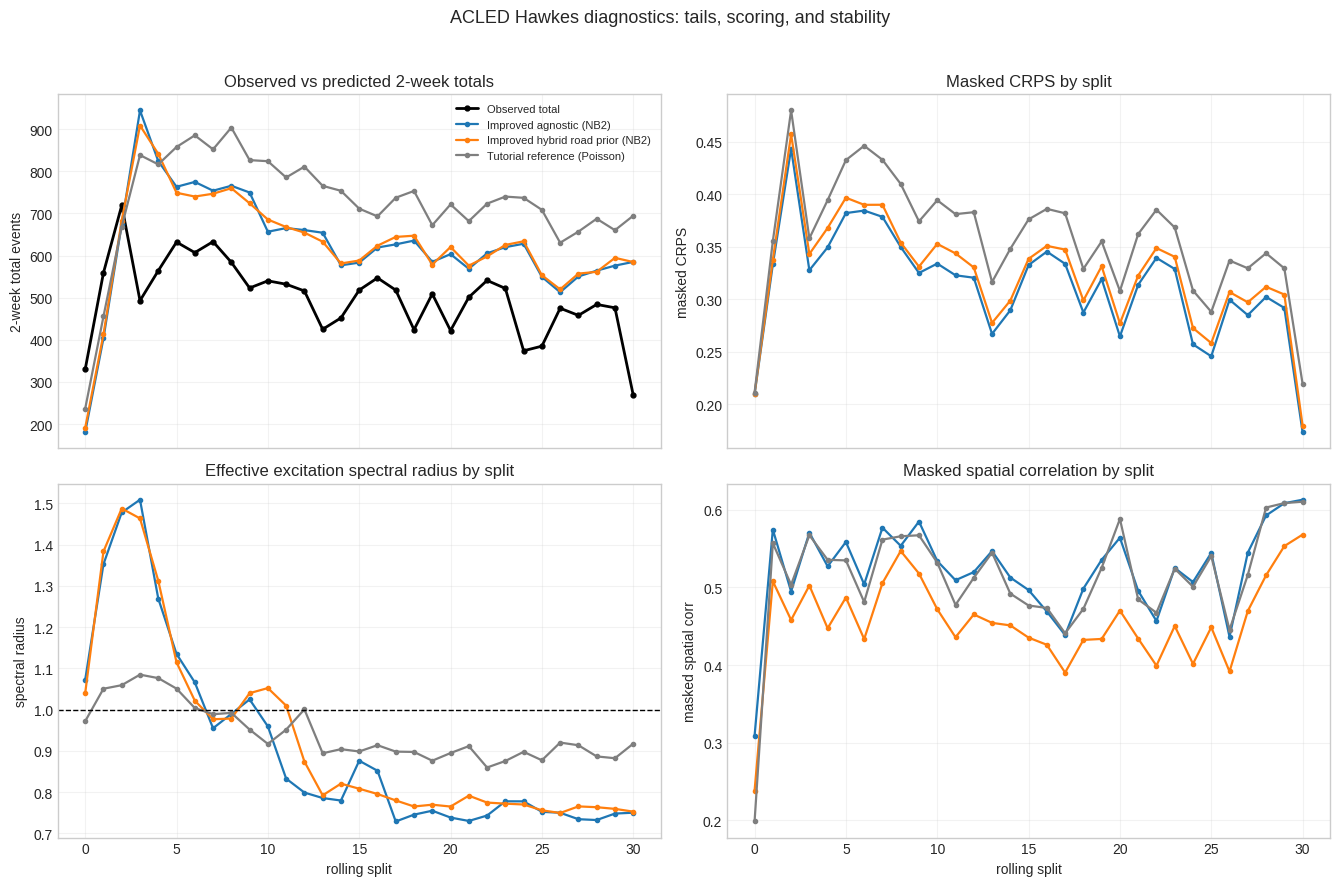

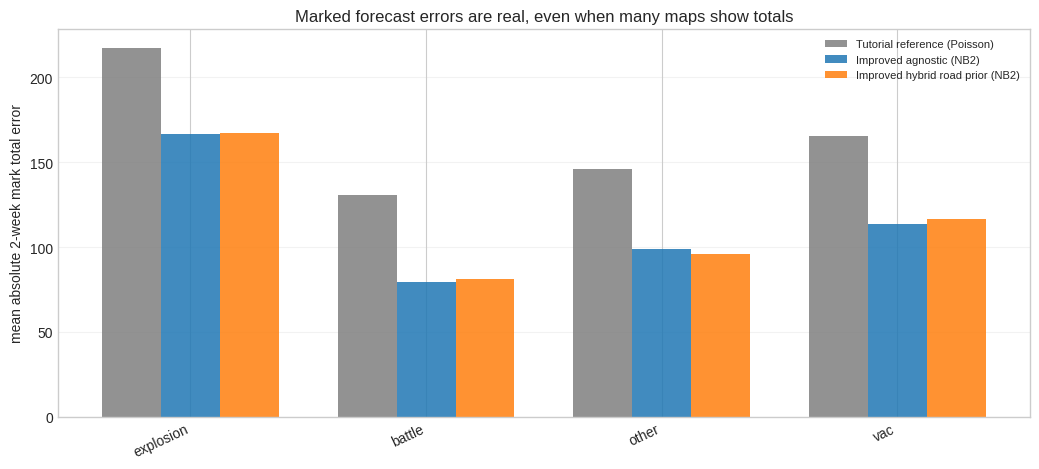

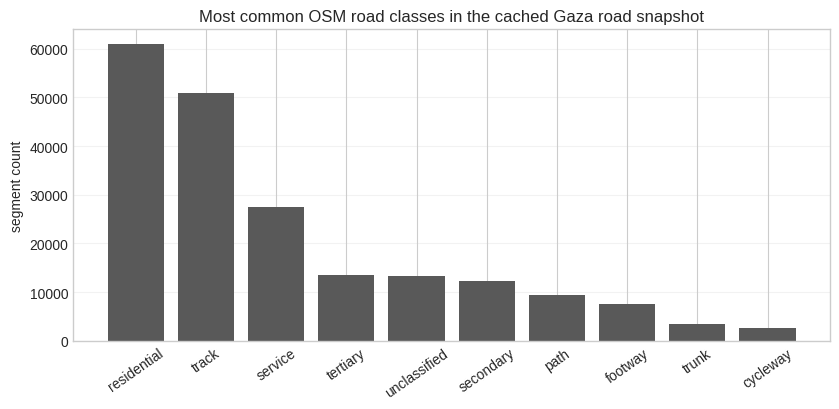

In [7]:
scenario_style = {
    "tutorial_reference_poisson": {"label": "Tutorial reference (Poisson)", "color": "tab:gray"},
    "improved_agnostic_nb2": {"label": "Improved agnostic (NB2)", "color": "tab:blue"},
    "improved_hybrid_nb2": {"label": "Improved hybrid road prior (NB2)", "color": "tab:orange"},
}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), sharex=True)

true_series = diag_all.groupby("split")["true_total"].first().sort_index()
axes[0, 0].plot(true_series.index, true_series.values, color="black", linewidth=2.0, marker="o", markersize=3.5, label="Observed total")
for scenario, dsub in diag_all.groupby("scenario"):
    style = scenario_style.get(scenario, {"label": scenario, "color": None})
    axes[0, 0].plot(
        dsub["split"],
        dsub["pred_total"],
        linewidth=1.6,
        marker="o",
        markersize=3.0,
        label=style["label"],
        color=style["color"],
    )
axes[0, 0].set_title("Observed vs predicted 2-week totals")
axes[0, 0].set_ylabel("2-week total events")
axes[0, 0].legend(frameon=False, fontsize=8)

for scenario, dsub in diag_all.groupby("scenario"):
    style = scenario_style.get(scenario, {"label": scenario, "color": None})
    axes[0, 1].plot(
        dsub["split"],
        dsub["masked_crps"],
        linewidth=1.6,
        marker="o",
        markersize=3.0,
        label=style["label"],
        color=style["color"],
    )
axes[0, 1].set_title("Masked CRPS by split")
axes[0, 1].set_ylabel("masked CRPS")

for scenario, dsub in diag_all.groupby("scenario"):
    style = scenario_style.get(scenario, {"label": scenario, "color": None})
    axes[1, 0].plot(
        dsub["split"],
        dsub["excitation_spectral_radius_mean"],
        linewidth=1.6,
        marker="o",
        markersize=3.0,
        label=style["label"],
        color=style["color"],
    )
axes[1, 0].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[1, 0].set_title("Effective excitation spectral radius by split")
axes[1, 0].set_ylabel("spectral radius")
axes[1, 0].set_xlabel("rolling split")

for scenario, dsub in diag_all.groupby("scenario"):
    style = scenario_style.get(scenario, {"label": scenario, "color": None})
    axes[1, 1].plot(
        dsub["split"],
        dsub["masked_spatial_corr"],
        linewidth=1.6,
        marker="o",
        markersize=3.0,
        label=style["label"],
        color=style["color"],
    )
axes[1, 1].set_title("Masked spatial correlation by split")
axes[1, 1].set_ylabel("masked spatial corr")
axes[1, 1].set_xlabel("rolling split")

for ax in axes.flat:
    ax.grid(alpha=0.25)

fig.suptitle("ACLED Hawkes diagnostics: tails, scoring, and stability", fontsize=13)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
plt.show()
plt.close(fig)

mark_err_cols = [c for c in diag_all.columns if c.startswith("abs_err_")]
mark_err_summary = (
    diag_all.groupby("scenario")[mark_err_cols]
    .mean()
    .rename(columns=lambda c: c.replace("abs_err_", ""))
    .T
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
bar_positions = np.arange(len(mark_err_summary.index))
bar_width = 0.25
scenario_order = [s for s in ["tutorial_reference_poisson", "improved_agnostic_nb2", "improved_hybrid_nb2"] if s in mark_err_summary.columns]
for i, scenario in enumerate(scenario_order):
    style = scenario_style.get(scenario, {"label": scenario, "color": None})
    ax.bar(
        bar_positions + (i - 0.5 * (len(scenario_order) - 1)) * bar_width,
        mark_err_summary[scenario].to_numpy(),
        width=bar_width,
        label=style["label"],
        color=style["color"],
        alpha=0.85,
    )
ax.set_xticks(bar_positions)
ax.set_xticklabels(mark_err_summary.index, rotation=25, ha="right")
ax.set_ylabel("mean absolute 2-week mark total error")
ax.set_title("Marked forecast errors are real, even when many maps show totals")
ax.legend(frameon=False, fontsize=8)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
plt.close(fig)

if not roads_df.empty:
    road_counts = roads_df["highway"].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.bar(road_counts.index, road_counts.values, color="0.35")
    ax.set_title("Most common OSM road classes in the cached Gaza road snapshot")
    ax.set_ylabel("segment count")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Representative spatial forecasts

The last section shows a few representative 2-week horizons as spatial maps. The point is not to inspect every split exhaustively, but to see whether the improved configurations recover the main conflict corridor structure without erasing local detail.

To keep the figure readable, we only show a small number of representative horizons: one of the heavier-count windows and one later window. The observed map is paired with the improved agnostic NB2 forecast, and when road data are available, the hybrid road-prior forecast is shown alongside it.

This is also the easiest way to see why the hybrid prior is more defensible than the pure road graph. The hybrid model is still allowed to use roads, but it does not force all spillover to live strictly on the snapped OSM graph.

/tmp/ipykernel_308345/4081196526.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))


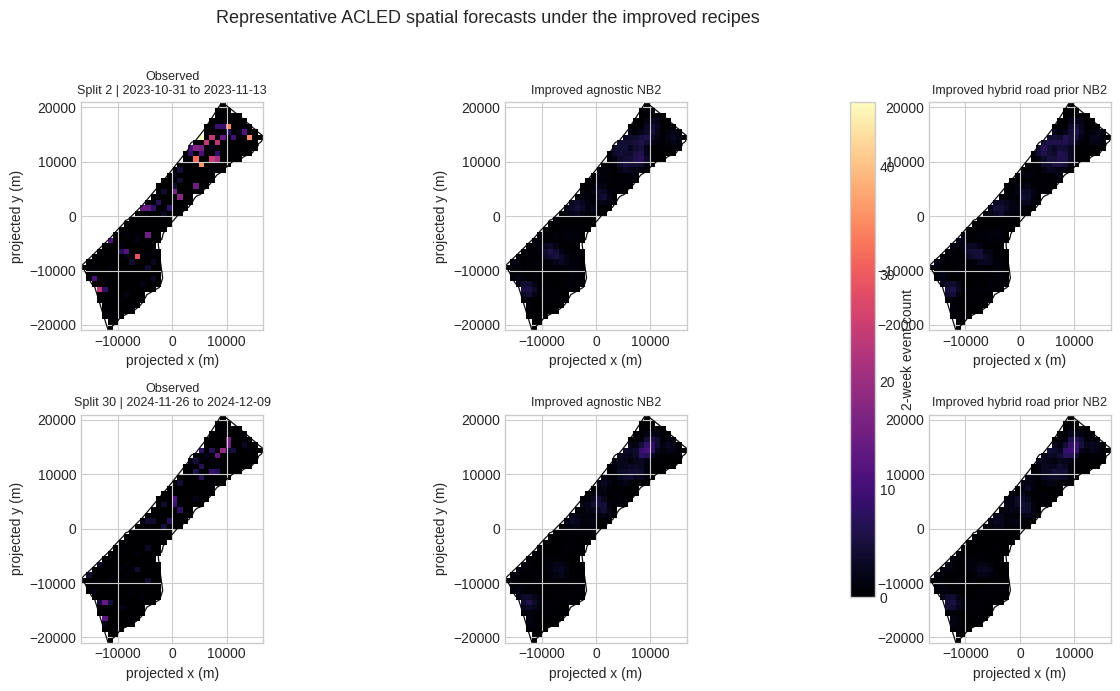

: 

In [ ]:
def plot_representative_spatial_rows(
    observed_bt,
    agnostic_bt,
    hybrid_bt=None,
    *,
    selected_split_ids: list[int],
) -> None:
    valid_ids = [split_id for split_id in selected_split_ids if 0 <= split_id < len(observed_bt["splits"])]
    if not valid_ids:
        print("No valid split ids selected for spatial plotting.")
        return

    maps_for_scale = []
    for split_id in valid_ids:
        maps_for_scale.append(np.asarray(observed_bt["splits"][split_id].test.y).sum(axis=(0, 2)).reshape(H, W))
        maps_for_scale.append(np.asarray(agnostic_bt["forecasts"][split_id].mean).sum(axis=(0, 2)).reshape(H, W))
        if hybrid_bt is not None:
            maps_for_scale.append(np.asarray(hybrid_bt["forecasts"][split_id].mean).sum(axis=(0, 2)).reshape(H, W))
    vmax = max(
        max(float(np.nanmax(apply_gaza_mask(arr))), 1.0)
        for arr in maps_for_scale
    )

    n_cols = 3 if hybrid_bt is not None else 2
    fig, axes = plt.subplots(len(valid_ids), n_cols, figsize=(4.25 * n_cols, 3.5 * len(valid_ids)), squeeze=False)

    for r, split_id in enumerate(valid_ids):
        split = observed_bt["splits"][split_id]
        observed_map = apply_gaza_mask(np.asarray(split.test.y).sum(axis=(0, 2)).reshape(H, W))
        agnostic_map = apply_gaza_mask(np.asarray(agnostic_bt["forecasts"][split_id].mean).sum(axis=(0, 2)).reshape(H, W))
        hybrid_map = None if hybrid_bt is None else apply_gaza_mask(np.asarray(hybrid_bt["forecasts"][split_id].mean).sum(axis=(0, 2)).reshape(H, W))

        test_start = pd.Timestamp(split.test.t0)
        test_end = test_start + pd.Timedelta(days=split.test.dt_days) - pd.Timedelta(days=1)
        row_label = f"Split {split_id} | {test_start.date()} to {test_end.date()}"

        im = axes[r, 0].imshow(observed_map, cmap="magma", vmin=0.0, vmax=vmax, origin="lower", extent=projected_extent, aspect="equal")
        draw_gaza_outline_projected(axes[r, 0], linewidth=0.9)
        axes[r, 0].set_title(f"Observed\n{row_label}", fontsize=9)
        axes[r, 0].set_xlabel("projected x (m)")
        axes[r, 0].set_ylabel("projected y (m)")

        axes[r, 1].imshow(agnostic_map, cmap="magma", vmin=0.0, vmax=vmax, origin="lower", extent=projected_extent, aspect="equal")
        draw_gaza_outline_projected(axes[r, 1], linewidth=0.9)
        axes[r, 1].set_title("Improved agnostic NB2", fontsize=9)
        axes[r, 1].set_xlabel("projected x (m)")
        axes[r, 1].set_ylabel("projected y (m)")

        if hybrid_bt is not None:
            axes[r, 2].imshow(hybrid_map, cmap="magma", vmin=0.0, vmax=vmax, origin="lower", extent=projected_extent, aspect="equal")
            draw_gaza_outline_projected(axes[r, 2], linewidth=0.9)
            axes[r, 2].set_title("Improved hybrid road prior NB2", fontsize=9)
            axes[r, 2].set_xlabel("projected x (m)")
            axes[r, 2].set_ylabel("projected y (m)")

    fig.colorbar(im, ax=axes, label="2-week event count", shrink=0.92)
    fig.suptitle("Representative ACLED spatial forecasts under the improved recipes", fontsize=13)
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
    plt.show()
    plt.close(fig)


top_split = int(diag_all.sort_values("true_total", ascending=False).iloc[0]["split"])
late_split = int(diag_all["split"].max())
selected_spatial_splits = sorted(set([top_split, late_split]))
plot_representative_spatial_rows(
    reference_bt,
    improved_agnostic_bt,
    improved_hybrid_bt,
    selected_split_ids=selected_spatial_splits,
)

## Practical takeaways

The current ACLED Hawkes notebook is not failing because the model forgot about marks. It is failing because a lightweight tutorial configuration was being read as a serious forecasting recipe. The most important practical fixes are to use an overdispersed likelihood, give the optimizer enough budget to find a meaningful solution, score the model on the Gaza mask rather than on a large sea of zeros, and treat roads as a soft prior instead of a hard replacement for local diffusion.

Even after those changes, there are still real limitations in the present implementation. The baseline rate is not node-specific, so persistent hotspot structure has to be absorbed by excitation. The spatial kernel is shared across marks. And the effective excitation process can still become too aggressive on some splits if the fit pushes toward large temporal mass. Those are not notebook issues; they are modeling limitations that point toward future code work.

Still, within the current implementation, the recipe in this notebook is a much better default for ACLED Gaza than the earlier tutorial-only setup. It gives a more honest evaluation, keeps the marked structure visible, and uses the road network in a way that is much closer to how a prior should behave in this application.

In [ ]:
elapsed = time.perf_counter() - NB_START
print(f"Notebook runtime: {elapsed:.1f} seconds")
print("Scored scenarios:", sorted(diag_all["scenario"].unique()))
print("Top-level recommendation: use the improved NB2 agnostic or hybrid-road recipe, not the tutorial Poisson setup, for ACLED-style forecasting.")

# ACLED Gaza Hawkes deep dive and practical improvements

This notebook is a focused follow-on to the rolling ACLED vignette. The goal here is not just to run the model, but to understand **why** the current example behaves the way it does and to put a more defensible modeling workflow into practice.

There are three questions motivating the analysis.

First, is the model actually marked, or are we effectively fitting a single total-count process? Second, why does the model struggle on large 2-week totals and spatial long tails? Third, why can a pure road prior perform worse than a simple agnostic spatial kernel even though roads seem like useful prior structure?

The short answers are these. The model **is** genuinely marked: the count tensor is `[T, J, M]`, the excitation matrix is mark-to-mark, and the forecast is generated jointly over marks. However, many of the headline plots in the earlier notebook collapse over the mark dimension, so the outputs *look* like total-only diagnostics. The heavy-count behavior is mainly a consequence of fitting a relatively parameter-rich Hawkes model with a **toy optimization budget**, a **Poisson observation model**, and only **one or two 2-week bins of history** in the earliest splits. The road-prior result is weaker because the notebook used a **pure road graph**, mapped an extremely rich OSM network onto a coarse lattice, and allowed footways, tracks, and other minor links to influence the prior almost as much as more plausible movement corridors.

In this notebook we keep the same deterministic ACLED snapshot and the same 2-week task framing, but we make four concrete changes.

We replace the Poisson likelihood with an NB2 count model so the forecast can express extra-Poisson dispersion. We increase the temporal basis count and give MAP fitting a real optimization budget instead of treating it as a toy run. We evaluate forecasts primarily **inside the Gaza mask** so the metrics are not dominated by always-zero cells outside the polygon. And instead of using a pure road graph as the only spatial pathway, we build a **hybrid local-plus-road prior** that treats roads as a soft directional cue rather than a hard replacement for local spillover.

The output is therefore both a diagnosis and an updated recipe for getting better behavior from the current mobility-Hawkes implementation on ACLED Gaza.